# Exploratory analysis — dengue UF × epidemiological week

Phase 1 EDA for the statistical baselines. Raw SINAN → probable-case panel → the three
load-bearing facts (overdispersion, annual cycle, 2024 anomaly) and the EW × year heatmap.

Aggregation follows `config.yml` / roadmap §1; this notebook is roadmap §2.

## Setup

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from arboviruses_series_forecasting.data import build_dengue_uf_ew_series
from arboviruses_series_forecasting.data.epidemiological.window import epiweek_of

REPO_ROOT = Path("..").resolve()
CONFIG_PATH = REPO_ROOT / "config.yml"

with CONFIG_PATH.open() as f:
    config = yaml.safe_load(f)

SINAN_PATH = REPO_ROOT / config["data"]["sinan"]["path"]
PROCESSED_PATH = REPO_ROOT / config["paths"]["processed"] / "dengue_uf_ew.parquet"
FIGURES_DIR = REPO_ROOT / config["paths"]["figures"]
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

WINDOW_START = config["aggregation"]["window"]["start"]
RIGHT_CENSOR_WEEKS = config["aggregation"]["right_censor_weeks"]

# Approximate UF centroid longitudes (°E) — west → east ordering for facets.
UF_LONGITUDE = {
    "AC": -70.55, "AM": -64.66, "RO": -63.07, "RR": -61.40, "PA": -52.29,
    "AP": -51.77, "MT": -55.98, "MS": -54.54, "TO": -48.30, "GO": -49.31,
    "DF": -47.93, "MA": -45.27, "PI": -42.80, "BA": -41.70, "MG": -44.38,
    "SP": -48.78, "PR": -51.55, "SC": -50.95, "RS": -53.00, "ES": -40.31,
    "RJ": -42.66, "CE": -39.32, "RN": -36.72, "PB": -36.72, "PE": -37.99,
    "AL": -36.62, "SE": -37.07,
}
UFS_WEST_TO_EAST = sorted(UF_LONGITUDE, key=UF_LONGITUDE.get)


def nature_style() -> None:
    mpl.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.05,
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "axes.linewidth": 0.6,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "lines.linewidth": 1.0,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


nature_style()
pd.set_option("display.width", 120)

assert SINAN_PATH.exists(), f"Missing extract: {SINAN_PATH}"
print(f"sinan:     {SINAN_PATH}")
print(f"processed: {PROCESSED_PATH}")
print(f"figures:   {FIGURES_DIR}")

sinan:     /home/caioolubini/Projects/arboviruses-series-forecasting/data/raw/SINAN_dengue_cases.parquet
processed: /home/caioolubini/Projects/arboviruses-series-forecasting/data/processed/dengue_uf_ew.parquet
figures:   /home/caioolubini/Projects/arboviruses-series-forecasting/docs/figures


## Aggregate to the forecasting panel

Probable cases (notified − discarded), UF × symptom-onset epidemiological week, from
`2010-EW01`, dropping the final 12 weeks of the extract for right-censoring.

In [2]:
dengue = build_dengue_uf_ew_series(
    SINAN_PATH,
    window_start=WINDOW_START,
    right_censor_weeks=RIGHT_CENSOR_WEEKS,
)
dengue = pd.concat([dengue, epiweek_of(dengue["week_start"])], axis=1)
dengue["log10_cases"] = np.log10(dengue["cases"] + 1)

PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
dengue.to_parquet(PROCESSED_PATH, index=False)

portrait = pd.Series(
    {
        "rows": f"{len(dengue):,}",
        "ufs": dengue["uf"].nunique(),
        "weeks": dengue["week_start"].nunique(),
        "span": f"{dengue['week_start'].min().date()} → {dengue['week_start'].max().date()}",
        "total_probable_cases": f"{int(dengue['cases'].sum()):,}",
        "saved": str(PROCESSED_PATH.relative_to(REPO_ROOT)),
    },
    name="value",
).to_frame()
portrait

,value
rows,"22,977"
ufs,27
weeks,851
span,2010-01-03 → 2026-04-19
total_probable_cases,"22,657,574"
saved,data/processed/dengue_uf_ew.parquet


## Three sentences (with numbers)

Roadmap §2 asks for exactly three claims. Supporting plots below make each claim checkable.

### 1. Overdispersion

Variance-to-mean ratio (VMR) of weekly counts, one value per UF.

Across UFs, weekly VMR ranges from 105 to 44933 (median 1129) — far above 1, so counts are strongly overdispersed.


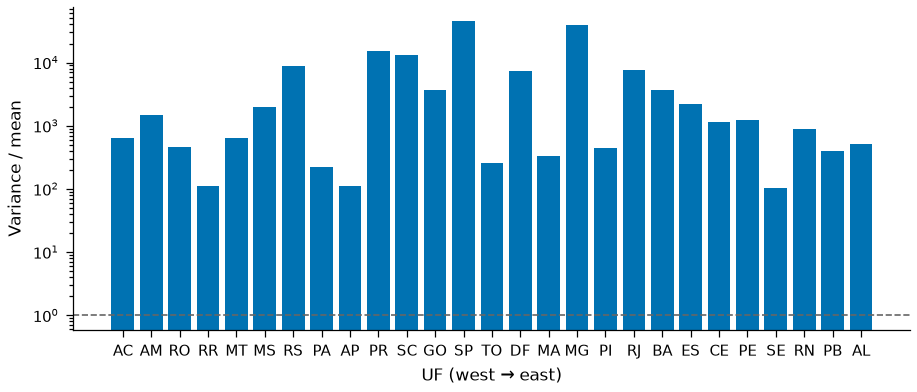

,mean,var,vmr
uf,,,
SE,54.1,5685.4,105.2
RR,21.7,2370.8,109.5
AP,39.4,4378.1,111.0
PA,191.5,41897.5,218.8
TO,158.6,40481.3,255.2
MA,134.6,44226.8,328.5
PB,261.7,105392.1,402.7
PI,174.1,77927.4,447.5
RO,107.0,49727.3,464.9


In [3]:
vmr = (
    dengue.groupby("uf")["cases"]
    .agg(mean="mean", var="var")
    .assign(vmr=lambda d: d["var"] / d["mean"])
    .sort_values("vmr")
)

vmr_min, vmr_max = vmr["vmr"].min(), vmr["vmr"].max()
print(
    f"Across UFs, weekly VMR ranges from {vmr_min:.0f} to {vmr_max:.0f} "
    f"(median {vmr['vmr'].median():.0f}) — far above 1, so counts are strongly overdispersed."
)

fig, ax = plt.subplots(figsize=(7.2, 2.8))
ordered = vmr.reindex([uf for uf in UFS_WEST_TO_EAST if uf in vmr.index])
ax.bar(ordered.index, ordered["vmr"], color="#0072B2", width=0.8)
ax.set_ylabel("Variance / mean")
ax.set_xlabel("UF (west → east)")
ax.set_yscale("log")
ax.axhline(1.0, color="0.4", lw=0.8, ls="--")
ax.tick_params(axis="x", labelrotation=0)
fig.savefig(FIGURES_DIR / "eda_overdispersion_vmr.pdf")
fig.savefig(FIGURES_DIR / "eda_overdispersion_vmr.png")
plt.show()

vmr[["mean", "var", "vmr"]].round(1)

### 2. Annual periodicity

Seasonal mean profile (pre-2024) and lag-52 autocorrelation on `log1p` counts — both point to `m = 52`.

Mean seasonal profile (2010–2023) peaks at EW15 and troughs at EW39; median UF autocorr of log1p counts is 0.51 at lag 52 vs -0.13 at lag 26 — annual period m = 52.


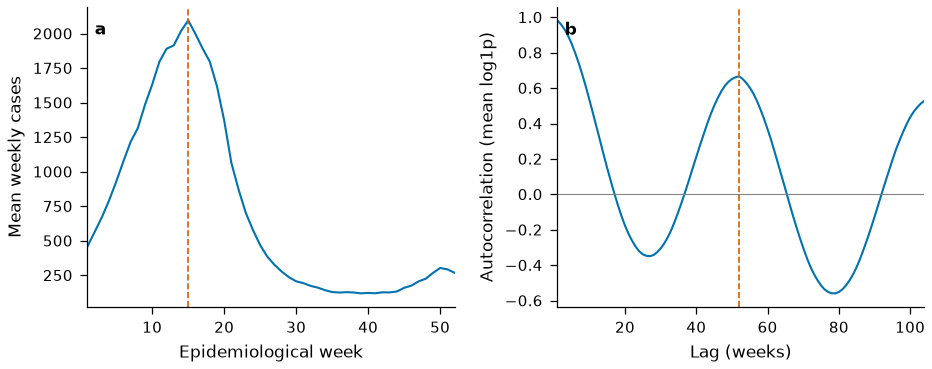

In [4]:
dengue["log1p_cases"] = np.log1p(dengue["cases"])

pre_2024 = dengue.loc[dengue["ew_year"] < 2024]
seasonal = (
    pre_2024.groupby("ew", as_index=False)["cases"]
    .mean()
    .query("ew <= 52")
)
peak_ew = int(seasonal.loc[seasonal["cases"].idxmax(), "ew"])
trough_ew = int(seasonal.loc[seasonal["cases"].idxmin(), "ew"])

acf52 = dengue.groupby("uf")["log1p_cases"].apply(lambda s: s.autocorr(lag=52))
acf26 = dengue.groupby("uf")["log1p_cases"].apply(lambda s: s.autocorr(lag=26))

print(
    f"Mean seasonal profile (2010–2023) peaks at EW{peak_ew} and troughs at EW{trough_ew}; "
    f"median UF autocorr of log1p counts is {acf52.median():.2f} at lag 52 "
    f"vs {acf26.median():.2f} at lag 26 — annual period m = 52."
)

fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.6), gridspec_kw={"wspace": 0.28})

axes[0].plot(seasonal["ew"], seasonal["cases"], color="#0072B2")
axes[0].axvline(peak_ew, color="#D55E00", lw=0.8, ls="--")
axes[0].set_xlabel("Epidemiological week")
axes[0].set_ylabel("Mean weekly cases")
axes[0].set_xlim(1, 52)
axes[0].text(0.02, 0.95, "a", transform=axes[0].transAxes, fontweight="bold", va="top")

lags = np.arange(1, 105)
national = dengue.groupby("week_start")["log1p_cases"].mean()
national_acf = [national.autocorr(lag=int(lag)) for lag in lags]
axes[1].plot(lags, national_acf, color="#0072B2")
axes[1].axvline(52, color="#D55E00", lw=0.8, ls="--")
axes[1].axhline(0, color="0.5", lw=0.5)
axes[1].set_xlabel("Lag (weeks)")
axes[1].set_ylabel("Autocorrelation (mean log1p)")
axes[1].set_xlim(1, 104)
axes[1].text(0.02, 0.95, "b", transform=axes[1].transAxes, fontweight="bold", va="top")

fig.savefig(FIGURES_DIR / "eda_annual_periodicity.pdf")
fig.savefig(FIGURES_DIR / "eda_annual_periodicity.png")
plt.show()

### 3. 2024 anomaly

Flag the year so it cannot silently dominate later error metrics.

2024 totalled 6,562,458 probable cases — 3.8× the previous annual maximum (1,720,095 in 2015) and 6.7× the 2010–2023 median.


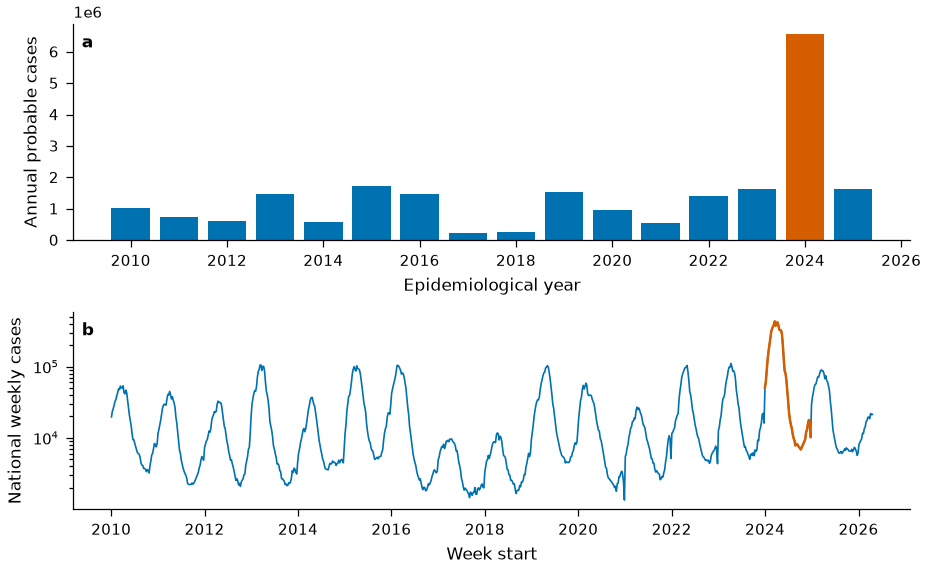

,probable_cases
ew_year,
2010,"1,015,861"
2011,"743,886"
2012,"597,901"
2013,"1,464,453"
2014,"588,250"
2015,"1,720,095"
2016,"1,484,901"
2017,"240,833"
2018,"266,414"


In [5]:
annual = dengue.groupby("ew_year")["cases"].sum().loc[2010:2025]
baseline_years = annual.loc[2010:2023]
ratio_to_prev_max = annual.loc[2024] / baseline_years.max()
ratio_to_median = annual.loc[2024] / baseline_years.median()

national_weekly = dengue.groupby("week_start", as_index=False)["cases"].sum()
national_weekly = pd.concat([national_weekly, epiweek_of(national_weekly["week_start"])], axis=1)

print(
    f"2024 totalled {int(annual.loc[2024]):,} probable cases — "
    f"{ratio_to_prev_max:.1f}× the previous annual maximum ({int(baseline_years.max()):,} in "
    f"{int(baseline_years.idxmax())}) and {ratio_to_median:.1f}× the 2010–2023 median."
)

fig, axes = plt.subplots(
    2, 1, figsize=(7.2, 4.2), sharex=False, gridspec_kw={"height_ratios": [1.1, 1], "hspace": 0.35}
)

colors = ["#D55E00" if year == 2024 else "#0072B2" for year in annual.index]
axes[0].bar(annual.index.astype(int), annual.values, color=colors, width=0.8)
axes[0].set_ylabel("Annual probable cases")
axes[0].set_xlabel("Epidemiological year")
axes[0].text(0.01, 0.95, "a", transform=axes[0].transAxes, fontweight="bold", va="top")

axes[1].plot(
    national_weekly["week_start"],
    national_weekly["cases"],
    color="#0072B2",
    lw=0.8,
)
mask_2024 = national_weekly["ew_year"] == 2024
axes[1].plot(
    national_weekly.loc[mask_2024, "week_start"],
    national_weekly.loc[mask_2024, "cases"],
    color="#D55E00",
    lw=1.2,
)
axes[1].set_ylabel("National weekly cases")
axes[1].set_xlabel("Week start")
axes[1].set_yscale("log")
axes[1].text(0.01, 0.95, "b", transform=axes[1].transAxes, fontweight="bold", va="top")

fig.savefig(FIGURES_DIR / "eda_2024_anomaly.pdf")
fig.savefig(FIGURES_DIR / "eda_2024_anomaly.png")
plt.show()

annual.map("{:,.0f}".format).to_frame("probable_cases")

## Main figure — `log10(I + 1)` by EW × year, UFs west → east

One panel per UF, ordered by centroid longitude. Shared colour scale so burden gradients
and the 2024 spike remain comparable across states.

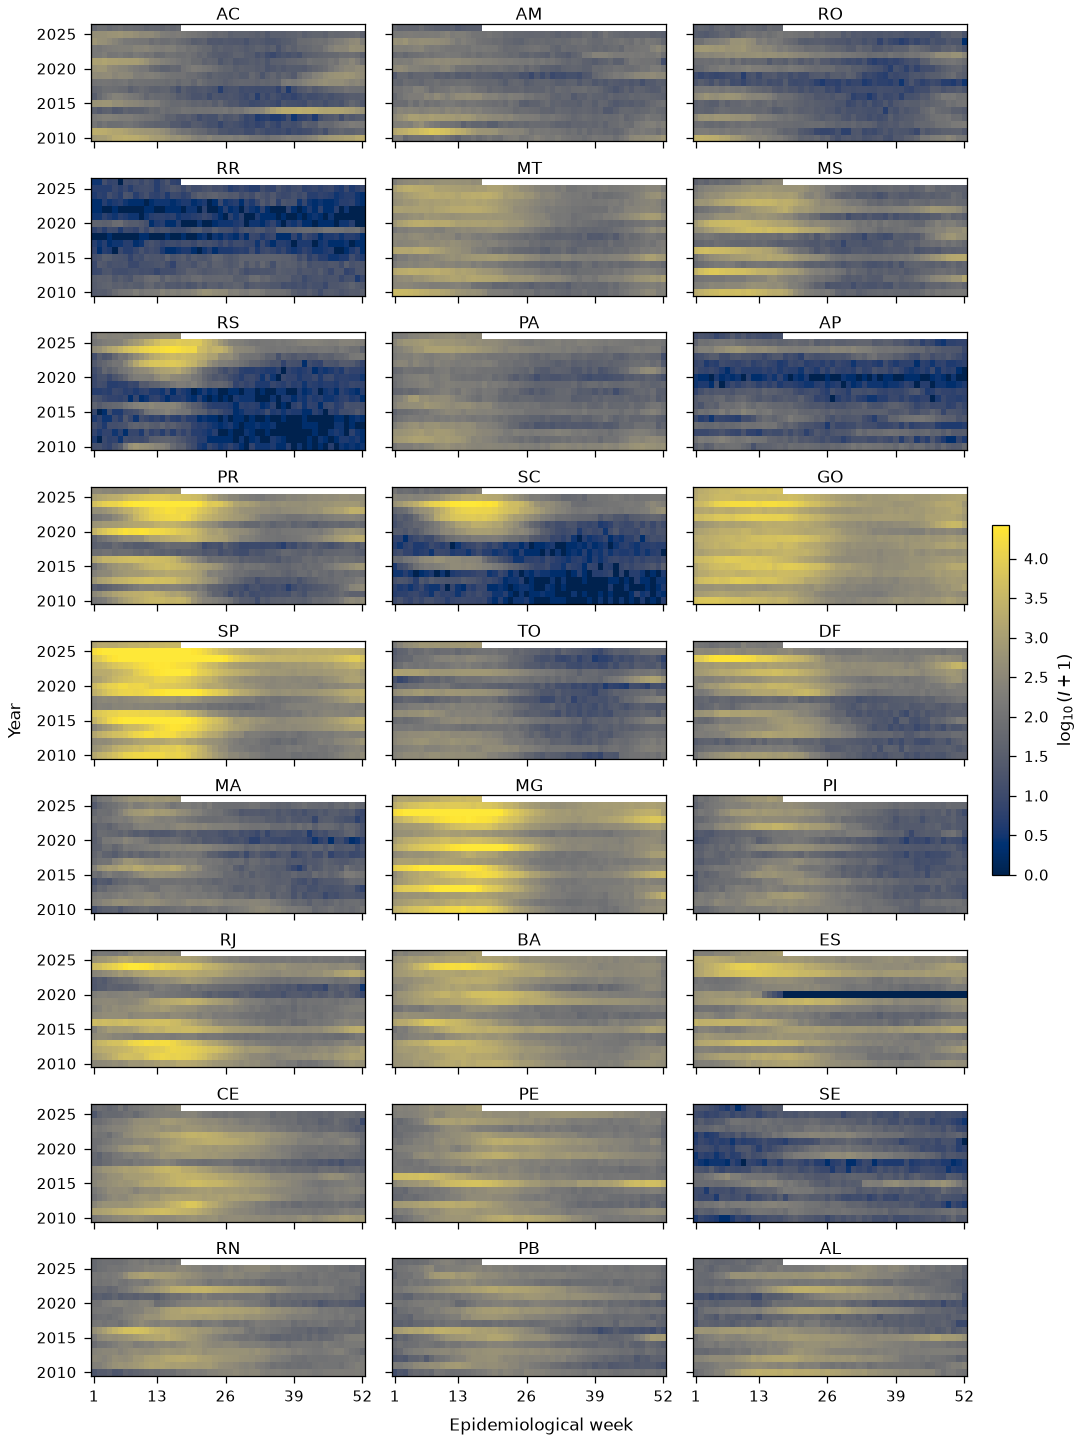

In [6]:
years = np.arange(dengue["ew_year"].min(), dengue["ew_year"].max() + 1)
ews = np.arange(1, 53)
vmax = dengue["log10_cases"].quantile(0.995)

n_ufs = len(UFS_WEST_TO_EAST)
n_cols = 3
n_rows = int(np.ceil(n_ufs / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(7.2, 9.6),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
axes_flat = np.asarray(axes).ravel()
cmap = plt.colormaps["cividis"]

last_mesh = None
for ax, uf in zip(axes_flat, UFS_WEST_TO_EAST):
    panel = (
        dengue.loc[dengue["uf"] == uf]
        .query("ew <= 52")
        .pivot_table(index="ew_year", columns="ew", values="log10_cases", aggfunc="mean")
        .reindex(index=years, columns=ews)
    )
    last_mesh = ax.pcolormesh(
        panel.columns.to_numpy(),
        panel.index.to_numpy(),
        panel.to_numpy(),
        cmap=cmap,
        vmin=0,
        vmax=vmax,
        shading="nearest",
        rasterized=True,
    )
    ax.set_title(uf, pad=2)
    ax.set_xlim(0.5, 52.5)
    ax.spines.top.set_visible(True)
    ax.spines.right.set_visible(True)

for ax in axes_flat[n_ufs:]:
    ax.set_visible(False)

for ax in axes_flat[:n_ufs]:
    ax.set_xticks([1, 13, 26, 39, 52])

fig.supxlabel("Epidemiological week", fontsize=8)
fig.supylabel("Year", fontsize=8)
cbar = fig.colorbar(last_mesh, ax=axes_flat[:n_ufs], fraction=0.02, pad=0.02)
cbar.set_label(r"$\log_{10}(I + 1)$")

fig.savefig(FIGURES_DIR / "eda_uf_ew_year_heatmap.pdf")
fig.savefig(FIGURES_DIR / "eda_uf_ew_year_heatmap.png")
plt.show()

## Takeaways for baselines

1. **Overdispersion** — weekly VMR ranges roughly **105–45,000** across UFs → model on `log1p` (or negative binomial), never raw MAE on counts.
2. **Annual periodicity** — seasonal peak near **EW15**, strong lag-**52** autocorrelation on `log1p` → Fourier / seasonal naive with `m = 52`.
3. **2024 anomaly** — about **3.8×** the prior annual maximum → treat as a held-out stress year in interpretation; do not let it silently set the skill score narrative.

Paper figure candidate: `docs/figures/eda_uf_ew_year_heatmap.pdf`.